# Análise dos dados fundiários - SIGEF/SNCI

## Imports

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv
import os
import time

## Paths

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
SIGEF_PATH = (
    f"gs://{BUCKET_NAME}/raw/land_tenure/Sigef Brasil_MG.shp"
)
SNCI_PATH = (
    f"gs://{BUCKET_NAME}/raw/land_tenure/Imóvel certificado SNCI Brasil_MG.shp"
)
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carregamento de dados

In [3]:
sigef_gdf = gpd.read_file(SIGEF_PATH)
snci_gdf = gpd.read_file(SNCI_PATH)
states_gdf = gpd.read_file(STATES_PATH)
print("Dados carregados com sucesso!")

Dados carregados com sucesso!


## Inspeção Inicial dos dados

In [6]:
print("\n--- Propriedades SIGEF (MG) ---")
print(f"CRS: {sigef_gdf.crs} | Quantidade: {len(sigef_gdf)}")
print(sigef_gdf.head())

print("\n--- Imóveis Certificados SNCI (MG) ---")
print(f"CRS: {snci_gdf.crs} | Quantidade: {len(snci_gdf)}")
print(snci_gdf.head())


--- Propriedades SIGEF (MG) ---
CRS: EPSG:4674 | Quantidade: 289630
                             parcela_co    rt                      art  \
0  423ac4ee-0b93-4c7a-ac1c-e8ea32a6f93d   GY3         CFT2201764081-MG   
1  93587dfe-d866-406e-9083-b8eccef05cd4  PABT         MG20220843901-MG   
2  6c8beacc-59a8-4518-823b-e3352e86be7c   ELM  14202000000005847946-MG   
3  7d4cda68-b702-4697-ad59-43dd28791033  URZA         MG20221273376-MG   
4  15348914-71d5-4b69-b349-37cc98fc9c79  URZA         MG20221273376-MG   

   situacao_i     codigo_imo data_submi data_aprov       status  \
0  REGISTRADA  4060580217505 2022-07-01 2022-07-05  CERTIFICADA   
1  REGISTRADA  4442600003370 2022-07-01 2022-07-05  CERTIFICADA   
2  REGISTRADA  9500765387014 2020-02-10 2020-02-11   REGISTRADA   
3  REGISTRADA  4090490070641 2022-07-04 2022-07-06  CERTIFICADA   
4  REGISTRADA  4090490070641 2022-07-04 2022-07-06  CERTIFICADA   

                                           nome_area registro_m registro_d  \
0  Fa

## Mapa Geral Fundiário

C:\Users\JPMar\AppData\Local\Temp\ipykernel_5376\492128210.py:27: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\JPMar\AppData\Local\Temp\ipykernel_5376\492128210.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


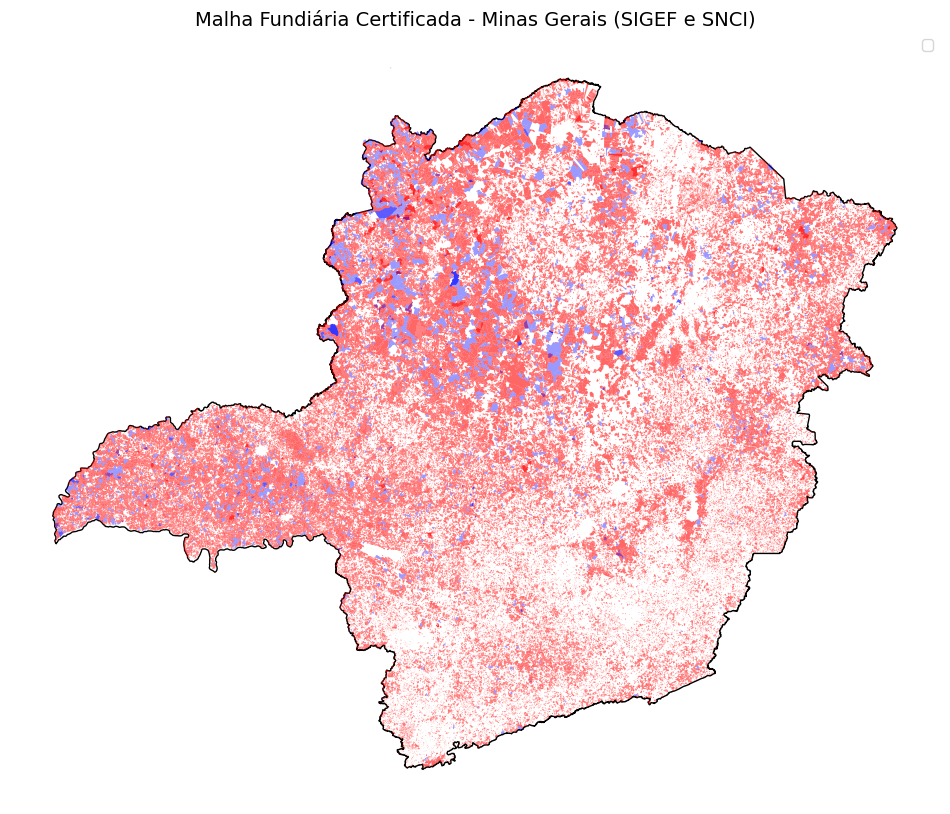

In [7]:
# 1. Filtrar apenas o polígono de Minas Gerais
mg_boundary = states_gdf[states_gdf['SIGLA_UF'] == 'MG'].copy()

# 2. Garantir que SIGEF e SNCI usem o mesmo CRS do mapa base (EPSG:4674)
# Isso evita que os pontos apareçam no "meio do mar" ou fora do lugar
if sigef_gdf.crs != mg_boundary.crs:
    sigef_gdf = sigef_gdf.to_crs(mg_boundary.crs)
if snci_gdf.crs != mg_boundary.crs:
    snci_gdf = snci_gdf.to_crs(mg_boundary.crs)

# 3. Gerar o Mapa
fig, ax = plt.subplots(figsize=(12, 12))

# Plotar o fundo de MG
mg_boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=1)

# Plotar os dados do SIGEF (em vermelho)
sigef_gdf.plot(ax=ax, color="red", linewidth=0.3, alpha=0.6, label="SIGEF")

# Plotar os dados do SNCI (em azul)
# Note: Se SNCI for polígono, use .plot(). Se for ponto, markersize ajuda.
snci_gdf.plot(ax=ax, color="blue", alpha=0.4, label="SNCI")

ax.set_title("Malha Fundiária Certificada - Minas Gerais (SIGEF e SNCI)", fontsize=14)
ax.set_axis_off() # Remove as bordas com lat/lon para um visual mais limpo

plt.legend()
plt.show()

## Normalizando e juntando os dados

In [11]:
print("1. Reprojetando para CRS métrico (EPSG:31983)...")
CRS_METRICO = "EPSG:31983"
sigef_proj = sigef_gdf.to_crs(CRS_METRICO)
snci_proj = snci_gdf.to_crs(CRS_METRICO)

1. Reprojetando para CRS métrico (EPSG:31983)...


In [14]:
print("2. Padronizando colunas e unificando as bases (SIGEF + SNCI)...")
# Padroniza SIGEF
sigef_clean = sigef_proj[['codigo_imo', 'nome_area', 'geometry']].rename(
    columns={'codigo_imo': 'id_imovel', 'nome_area': 'nome_imovel'}
)
sigef_clean['fonte'] = 'SIGEF'

# Padroniza SNCI
snci_clean = snci_proj[['cod_imovel', 'nome_imove', 'geometry']].rename(
    columns={'cod_imovel': 'id_imovel', 'nome_imove': 'nome_imovel'}
)
snci_clean['fonte'] = 'SNCI'

fundiario_unificado = pd.concat([sigef_clean, snci_clean], ignore_index=True)
fundiario_unificado = gpd.GeoDataFrame(fundiario_unificado, geometry='geometry', crs=CRS_METRICO)

2. Padronizando colunas e unificando as bases (SIGEF + SNCI)...


## Filtrando propriedades com > 100 hectares

In [17]:
total_original = len(fundiario_unificado)
print(f"Total de propriedades unificadas antes do filtro: {total_original:,}")

print("\n3. Calculando área e selecionando latifúndios (>= 100 hectares)...")
# Calcula a área (geometry.area retorna m², dividimos por 10.000 para ha)
fundiario_unificado['area_calculada_ha'] = fundiario_unificado.geometry.area / 10000

# Aplica o filtro de 100 hectares
fundiario_100 = fundiario_unificado[fundiario_unificado['area_calculada_ha'] >= 100].copy()
perc_reducao = (1 - (len(fundiario_100) / total_original)) * 100

print("\n4. Retornando ao CRS padrão do projeto (EPSG:4674)...")
fundiario_mg = fundiario_100.to_crs("EPSG:4674")

print(f"Propriedades Mantidas (> 100 ha): {len(fundiario_mg):,}")
print(fundiario_mg.head())

Total de propriedades unificadas antes do filtro: 293,780

3. Calculando área e selecionando latifúndios (>= 100 hectares)...

4. Retornando ao CRS padrão do projeto (EPSG:4674)...
Propriedades Mantidas (> 100 ha): 63,712
        id_imovel                                        nome_imovel  \
10  9501064978006                           FAZENDA BOM JARDIM - 001   
14  4240990011716                   Fazenda Mata dos Ruas - Gleba 01   
17  4230920122892                        Fazenda Barcelos  - Parte 1   
18  4150810073825  ?FAZENDA BOA VISTA?, LUGAR DENOMINADO ?CABECEI...   
21  4010560354401  Fazenda Bom Jardim do Rio Pardo - Fazenda Bom ...   

                                             geometry  fonte  \
10  POLYGON Z ((-50.14225 -19.06351 482.299, -50.1...  SIGEF   
14  POLYGON Z ((-45.90771 -19.56573 948.27, -45.90...  SIGEF   
17  POLYGON Z ((-47.18546 -20.09893 958.51, -47.18...  SIGEF   
18  POLYGON Z ((-47.93816 -18.87952 847.04, -47.93...  SIGEF   
21  POLYGON Z ((-44.83619

<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
C:\Users\JPMar\AppData\Local\Temp\ipykernel_5376\4116859157.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Malha Fundiária Filtrada - Minas Gerais\n({len(fundiario_mg):,} Latifúndios $\geq$ 100 hectares)", fontsize=14, fontweight='bold')


Gerando mapa da malha fundiária filtrada...


C:\Users\JPMar\AppData\Local\Temp\ipykernel_5376\4116859157.py:40: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Base de Origem', loc='lower left')
C:\Users\JPMar\AppData\Local\Temp\ipykernel_5376\4116859157.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Base de Origem', loc='lower left')


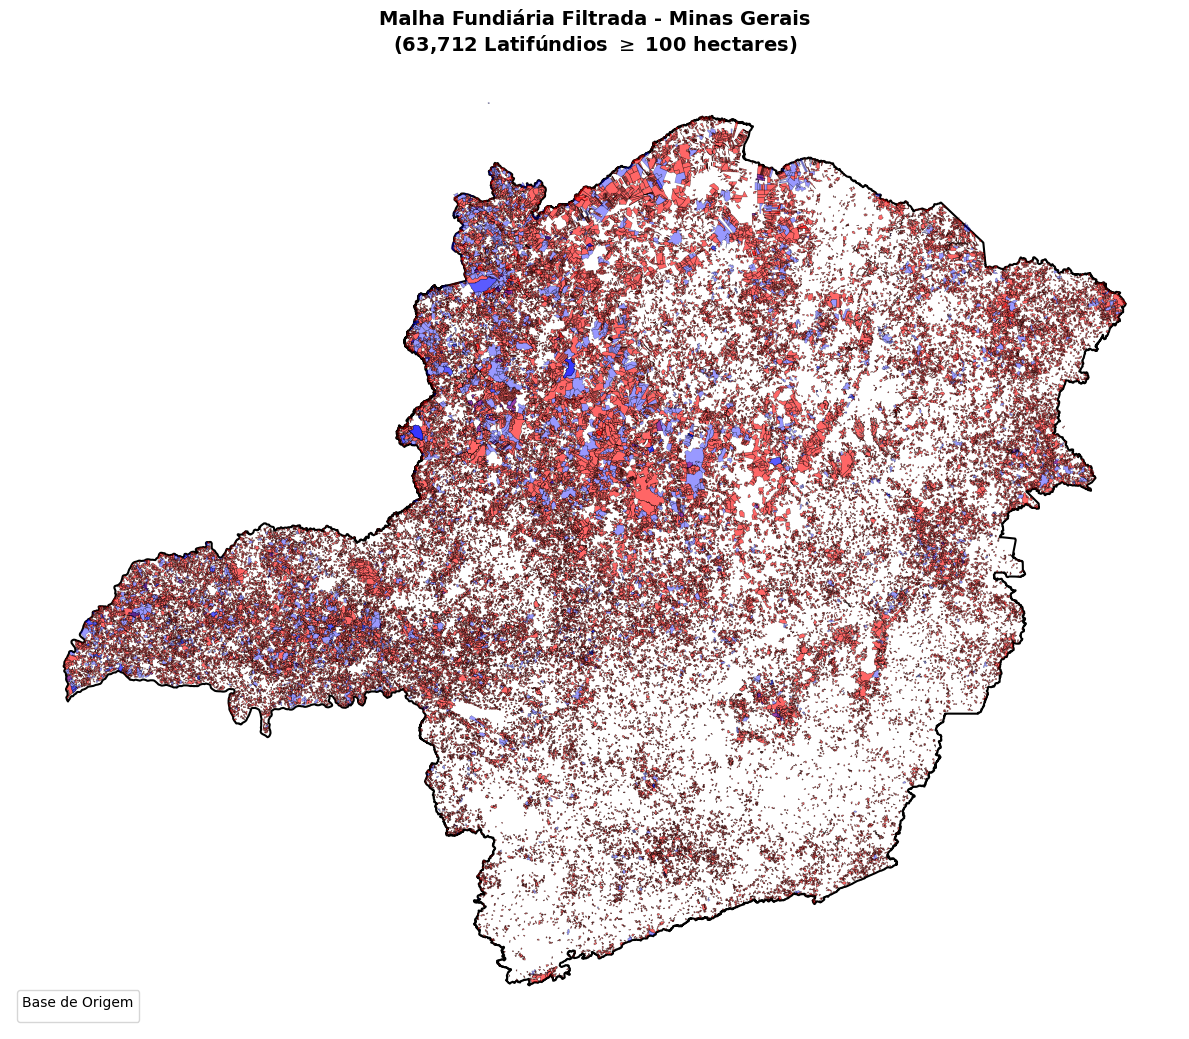

In [20]:
# ==============================================================================
# CÉLULA 7: VISUALIZAÇÃO DOS LATIFÚNDIOS (> 100 ha) EM MINAS GERAIS
# ==============================================================================
import matplotlib.pyplot as plt

print("Gerando mapa da malha fundiária filtrada...")

fig, ax = plt.subplots(figsize=(12, 12))

# 1. Plota o limite de Minas Gerais como mapa base
mg_boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=1.5)

# 2. Plota os latifúndios do SIGEF (Vermelho)
sigef_mask = fundiario_mg['fonte'] == 'SIGEF'
fundiario_mg[sigef_mask].plot(
    ax=ax, 
    color="red", 
    alpha=0.6, 
    linewidth=0.3,
    edgecolor='black',
    label='SIGEF'
)

# 3. Plota os latifúndios do SNCI (Azul)
snci_mask = fundiario_mg['fonte'] == 'SNCI'
fundiario_mg[snci_mask].plot(
    ax=ax, 
    color="blue", 
    alpha=0.4, 
    linewidth=0.3,
    edgecolor='black',
    label='SNCI'
)

# 4. Ajustes visuais
ax.set_title(f"Malha Fundiária Filtrada - Minas Gerais\n({len(fundiario_mg):,} Latifúndios $\geq$ 100 hectares)", fontsize=14, fontweight='bold')
ax.set_axis_off() # Esconde os eixos de latitude/longitude

# Força a exibição da legenda com base nas labels definidas acima
ax.legend(title='Base de Origem', loc='lower left')

plt.tight_layout()
plt.show()